# CMSE 801 - Day 17
## Regression

### Nov 7, 2022

## General Course Announcements

* Homework #4 is due Monday Nov 14 at 11:59 p.m. 
* Project's deadline Sunday Dec 4 at 11:59 p.m.
* Return on HW-03

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import odeint
from scipy import optimize
from scipy.optimize import curve_fit

In [2]:
def deriv_func(curr_val,t,mu1,Ks,mu2):
    cm, cn = curr_val
    dcmdt = mu1*cn*cm/(Ks+cn)
    dcndt = -mu2*cn*cm/(Ks+cn)
    return dcmdt, dcndt

In [3]:
def computeApproxMonodModel(param,y0,time_grid):
    mu1 = param[0]
    Ks = param[1]
    mu2 = param[2]
    solution = odeint(deriv_func, y0, time_grid, args=(mu1, Ks, mu2)) 
    cM = solution[:,0]
    cN = solution[:,1]
    return cM, cN 

In [4]:
def CNCM(t):
    y0 = [0.03, 0.3]
    param = [0.05, 0.3, 0.3]
    time_grid = np.linspace(0,t,2)
    CM,CN = computeApproxMonodModel(param,y0,time_grid) 
    res = CM[-1]-CN[-1]
    return res

In [5]:
sol_cNcM = optimize.root_scalar(CNCM,x0=0.1,x1=0.3)
y0 = [0.03, 0.3]
param = [0.05, 0.3, 0.3]
time_grid = np.arange(0,400+0.1,0.1)
cM, cN = computeApproxMonodModel(param,y0,time_grid)

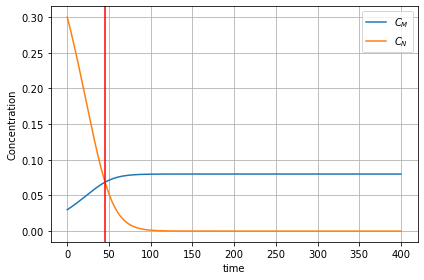

In [6]:
plt.plot(time_grid,cM,label='$C_M$')
plt.plot(time_grid,cN,label='$C_N$')
plt.axvline(sol_cNcM.root,color='red')
plt.xlabel('time')
plt.ylabel('Concentration')
plt.legend()
plt.grid()
plt.tight_layout()

## Questions/comments from Day 17 PCA

* Go over the curve fit again. Also, do you only pass x value from the function you create from poly1d here :  my_poly_function(x)
* Is there a way to also calculate the Pearson Correlation coefficient with the polynomial regressions?
* Is that possible to go over the idea(s) of np.polyfit and np.polyld
* How can I get the R-square values for the linear regression in python?
* Will we be going over how to produce regression tables and coefficient plots? In my field we don't really just plot a scatter with a regression line...
* Is there a function to calculate the correlation coefficient for the calculated regression?

* If we do not know the correlation (linear, logarithmic or others) between x and y, how can we choose the type of regression? I mean how can we know the regression type we choose is reasonable?
* Finally, we're getting to a topic I use every single day in my work! I'm very excited about this one. Thanks, Yann and Jim!
* Final project but I will come to office hours on monday

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

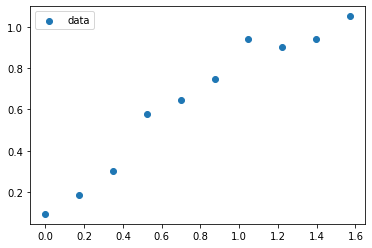

In [8]:
x = np.linspace(0,np.pi/2,10)
y = np.sin(x) + 0.1*np.random.randn(10)
plt.scatter(x, y, label = "data")
plt.legend()
plt.show()

In [9]:
# use np.polyfit to get the parameters for our polynomial regression
poly_parameters = np.polyfit(x, y, 2)
print(poly_parameters)

[-0.27314095  1.05909697  0.04423129]


In [10]:
my_poly_function = np.poly1d(poly_parameters)
print(type(my_poly_function))
print(my_poly_function)

<class 'numpy.poly1d'>
         2
-0.2731 x + 1.059 x + 0.04423


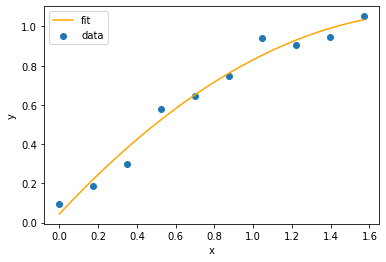

In [13]:
# initialize our predicted y values from the my_poly_function created using np.poly1d
x_fine = np.linspace(np.min(x),np.max(x),100)
expected_y_poly = my_poly_function(x_fine)

plt.scatter(x, y, label = "data")
plt.plot(x_fine, expected_y_poly, color = "orange", label = "fit")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [14]:
def sin_function(x, A, B, C):
    y =  A * np.sin(B * x + C)
    return y

In [15]:
best_fit_parameters_sin, pcov = curve_fit(sin_function, x, y)
print(best_fit_parameters_sin)

[1.02533071 0.90605229 0.05306118]


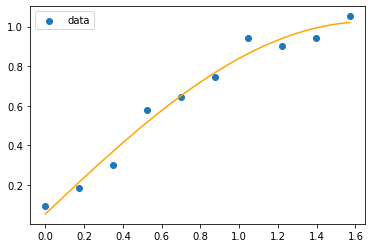

In [16]:
x_fine = np.linspace(min(x),max(x),100)
expected_y = sin_function(x_fine,best_fit_parameters_sin[0],best_fit_parameters_sin[1],best_fit_parameters_sin[2])
plt.scatter(x, y, label = "data")
plt.plot(x_fine, expected_y, color = "orange")
plt.legend()

* Function for the Pearson correlation coefficient can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
* Function for the R-square value can be found [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)